In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats

In [2]:
df = pd.read_csv('cleaned_googleplaystore.csv')

In [3]:
df.shape

(9659, 14)

In [4]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,2544,Facebook,social,4.1,78158306.0,12.0,1000000000,free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,381,WhatsApp Messenger,communication,4.4,69119316.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,2604,Instagram,social,4.5,66577446.0,12.0,1000000000,free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,382,Messenger – Text and Video Chat for Free,communication,4.0,56646578.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,1879,Clash of Clans,game,4.6,44893888.0,98.0,100000000,free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          9659 non-null   float64
 4   Reviews         9659 non-null   float64
 5   Size            9659 non-null   float64
 6   Installs        9659 non-null   int64  
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   float64
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9659 non-null   object 
 13  Android Ver     9659 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 1.0+ MB


### Divide the EDA into levels
#### Univariate ---> installs, reviews, ratings 
#### Bivariate  ---> (ratings, reviews)
#### Multivariate

# Part-1: Univariate Analysis

In [6]:
# Analyse the distribution of Ratings
df['Rating'].describe()

count    9659.000000
mean        4.176307
std         0.494022
min         1.000000
25%         4.000000
50%         4.200000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

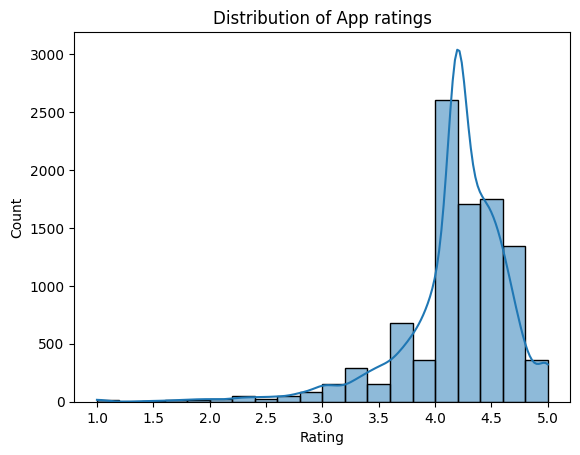

In [7]:
# Visualise the distribution
sns.histplot(data=df, x='Rating', bins=20, kde=True)
plt.title("Distribution of App ratings")
plt.show()

In [8]:
# variance and std
df['Rating'].var()

np.float64(0.24405808508283555)

In [9]:
df['Rating'].std()

np.float64(0.49402235281699103)

In [10]:
# percentile
df['Rating'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.99])

0.01    2.3
0.05    3.2
0.25    4.0
0.50    4.2
0.75    4.5
0.99    5.0
Name: Rating, dtype: float64

In [11]:
q1 = df['Rating'].quantile(0.25)
q3 = df['Rating'].quantile(0.75)

IQR = q3-q1
print("IQR", IQR)

IQR 0.5


In [12]:
# Skewness
df['Rating'].skew()


np.float64(-1.9122166217373762)

In [13]:
# kurtosis
# positive value means that it has a long tail and a sharp peak --- >the data contains more extreme values
# Negative value means the distribution is light tailed and has no sharp peak
# close to zero means close to perfect normal distribution

df['Rating'].kurt()

np.float64(6.628402486669086)

In [14]:
# Analyse the reviews
df['Reviews'].describe()

count    9.659000e+03
mean     2.168041e+05
std      1.831430e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.690000e+02
75%      2.945350e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [15]:
df['Reviews'].skew()

np.float64(26.5697582111809)

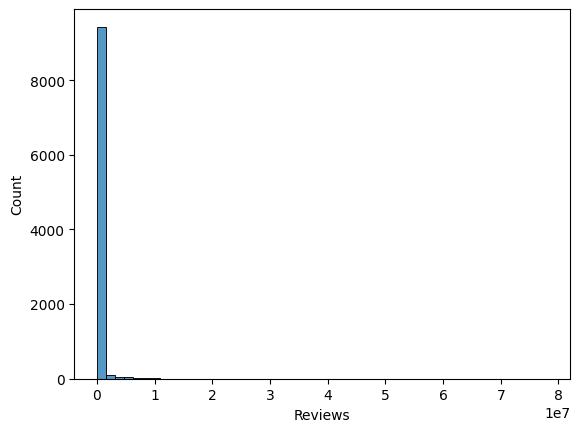

In [16]:
sns.histplot(data=df, x='Reviews', bins=50)
plt.show()

In [18]:
df['log_reviews'] = np.log1p(df['Reviews'])

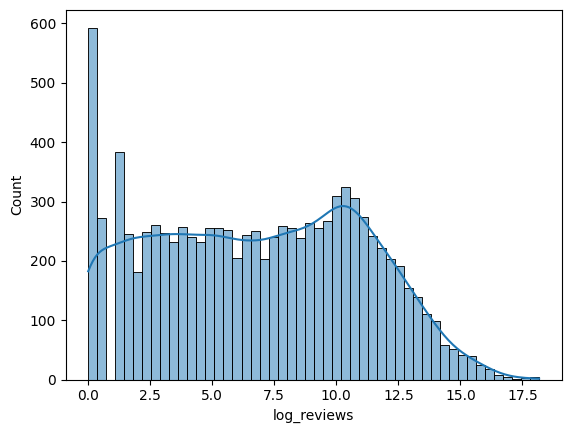

In [21]:
sns.histplot(data=df, x='log_reviews', bins=50, kde=True)
plt.show()

In [22]:
# Analyse installs
df['Installs'].describe()

count    9.659000e+03
mean     7.798170e+06
std      5.376973e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [23]:
df['Installs'].skew()

np.float64(15.027397537641702)

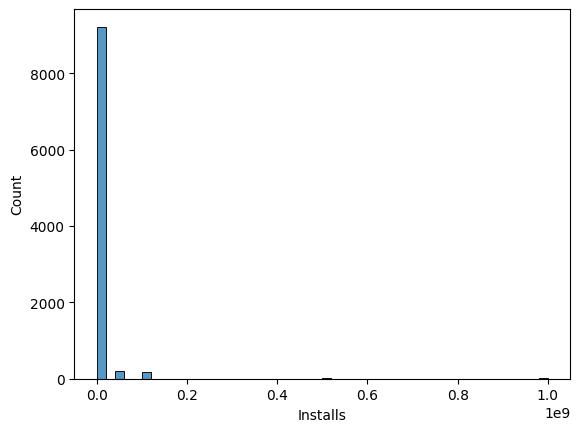

In [24]:
sns.histplot(data=df, x='Installs', bins=50)
plt.show()

In [25]:
df['log_installs'] = np.log1p(df['Installs'])

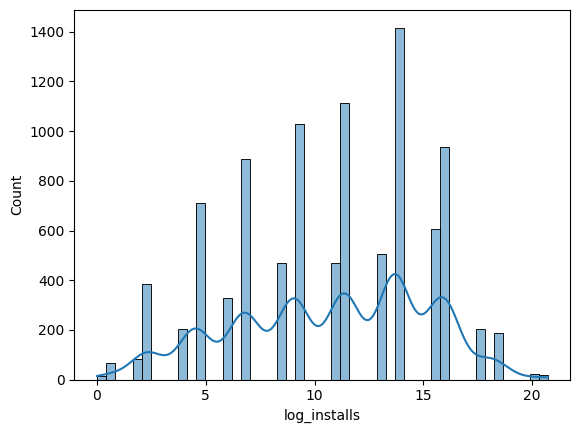

In [27]:
sns.histplot(data=df, x='log_installs', bins=50, kde=True)
plt.show()

In [28]:
# Price
df['Price'].describe()

count    9659.000000
mean        1.097231
std        16.851618
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

[]

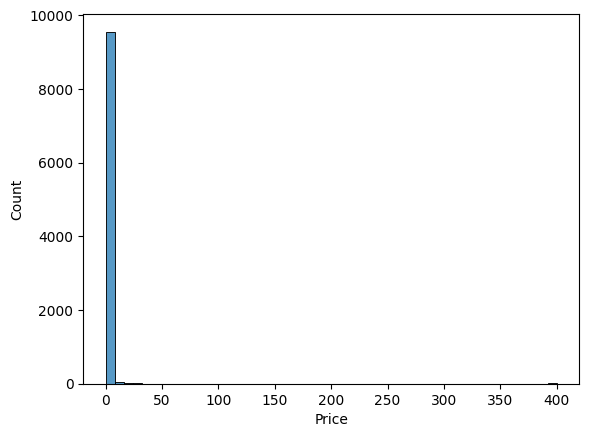

In [29]:
sns.histplot(data=df, x='Price', bins=50)
plt.plot()

In [30]:
paid = df[df['Price'] > 0]
paid['Price'].describe()

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

## Categorical EDA

In [32]:
# i want to see the count from each category
df['Category'].value_counts()

Category
family                 1875
game                    945
tools                   829
business                420
medical                 395
personalization         376
productivity            374
lifestyle               369
finance                 345
sports                  325
communication           315
health_and_fitness      288
photography             281
news_and_magazines      254
social                  239
books_and_reference     222
travel_and_local        219
shopping                202
dating                  170
video_players           164
maps_and_navigation     131
food_and_drink          112
education               107
entertainment            87
auto_and_vehicles        85
libraries_and_demo       84
weather                  79
house_and_home           73
events                   64
art_and_design           61
parenting                60
comics                   56
beauty                   53
Name: count, dtype: int64

In [33]:
df['Category'].value_counts(normalize=True)*100

Category
family                 19.411947
game                    9.783621
tools                   8.582669
business                4.348276
medical                 4.089450
personalization         3.892743
productivity            3.872036
lifestyle               3.820271
finance                 3.571798
sports                  3.364738
communication           3.261207
health_and_fitness      2.981675
photography             2.909204
news_and_magazines      2.629672
social                  2.474376
books_and_reference     2.298375
travel_and_local        2.267315
shopping                2.091314
dating                  1.760017
video_players           1.697898
maps_and_navigation     1.356248
food_and_drink          1.159540
education               1.107775
entertainment           0.900714
auto_and_vehicles       0.880008
libraries_and_demo      0.869655
weather                 0.817890
house_and_home          0.755772
events                  0.662594
art_and_design          0.631535
p

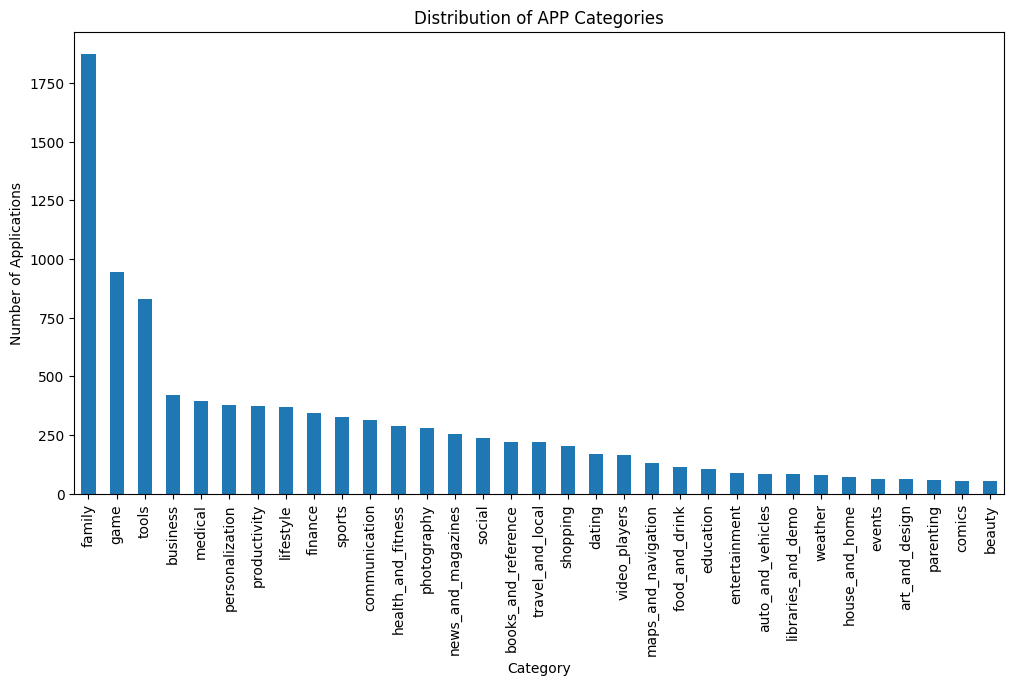

In [34]:
plt.figure(figsize=(12, 6))
df['Category'].value_counts().plot(kind="bar")

plt.ylabel("Number of Applications")
plt.title("Distribution of APP Categories")
plt.show()

## Outlier Detection

In [35]:
# Detecting outliers using IQR
# Reviews

q1 = df['Reviews'].quantile(0.25)
q3 = df['Reviews'].quantile(0.75)

IQR = q3-q1

lower = q1 - 1.5*IQR 
upper = q3 + 1.5*IQR 

# read about this what happens if the distribution is different

outliers = df[(df['Reviews'] < lower) | (df['Reviews'] > upper)]

outliers.shape

(1659, 16)

In [37]:
outliers[['App', 'Category', 'Reviews', 'Installs', 'Rating']].sort_values("Reviews", ascending=False).head(20)

,App,Category,Reviews,Installs,Rating
0,Facebook,social,78158306.0,1000000000,4.1
1,WhatsApp Messenger,communication,69119316.0,1000000000,4.4
2,Instagram,social,66577446.0,1000000000,4.5
3,Messenger – Text and Video Chat for Free,communication,56646578.0,1000000000,4.0
4,Clash of Clans,game,44893888.0,100000000,4.6
5,Clean Master- Space Cleaner & Antivirus,tools,42916526.0,500000000,4.7
6,Subway Surfers,game,27725352.0,1000000000,4.5
7,YouTube,video_players,25655305.0,1000000000,4.3
8,"Security Master - Antivirus, VPN, AppLock, Boo...",tools,24900999.0,500000000,4.7
9,Clash Royale,game,23136735.0,100000000,4.6


## Bivariate Analysis

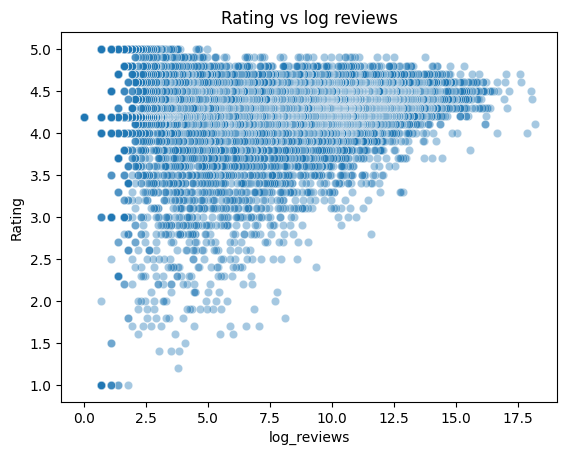

In [38]:
# Ratings VS Reviews
# Question: Do apps with more reviews tends to have better rating?

sns.scatterplot(data=df, x='log_reviews', y='Rating', alpha=0.4)
plt.title("Rating vs log reviews")
plt.show()

In [40]:
# Pearson correlation
df[['Rating', 'Reviews']].corr(method='pearson')

,Rating,Reviews
Rating,1.00000,0.05435
Reviews,0.05435,1.00000


In [41]:
# Spearman
df[['Rating', 'Reviews']].corr(method='spearman')

,Rating,Reviews
Rating,1.00000,0.20068
Reviews,0.20068,1.00000


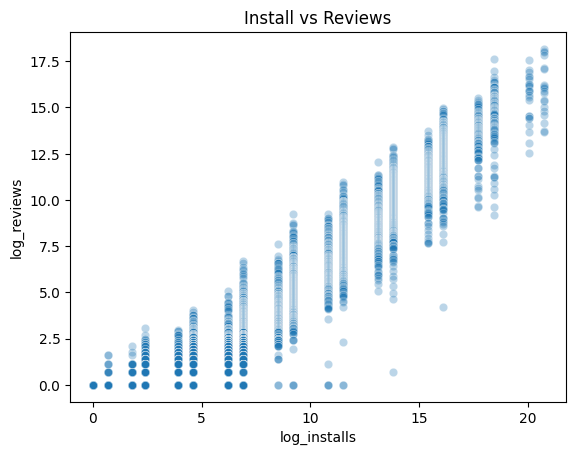

In [42]:
# Installs vs Reviews
sns.scatterplot(data=df, x='log_installs', y='log_reviews', alpha=0.3)
plt.title("Install vs Reviews")
plt.show()

In [43]:
df[['log_installs', 'log_reviews']].corr(method='pearson')

,log_installs,log_reviews
log_installs,1.000000,0.958784
log_reviews,0.958784,1.000000


In [45]:
# Group Analysis
# Free Vs Paid
# Q: Do free Apps have different rating than paid apps?

df.groupby('Type')['Rating'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
Type,,,,
free,8905,4.170215,4.2,0.493216
paid,754,4.248259,4.3,0.498165


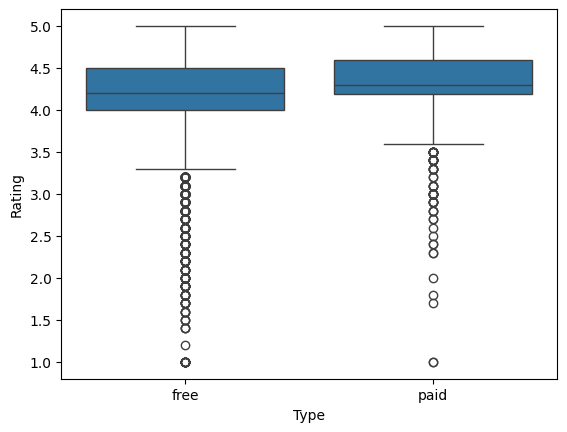

In [46]:
sns.boxplot(data=df, x='Type', y='Rating')
plt.show()

### Formulate the Hypothesis

#### Null Hypothesis
> ##### $H_0: \mu{free} = \mu{paid}$
#### Alternate Hypothesis
> ##### $H_a: \mu{free} \ne \mu{paid}$

In [51]:
# Welch's T-test
free_rating = df.loc[df['Price'] == np.float16(0), "Rating"]
paid_rating = df.loc[df['Price'] > 0, "Rating"]

In [53]:
t_stat, p_value = stats.ttest_ind(free_rating, paid_rating, equal_var=False)
print("t-stats", t_stat)
print("p_value", p_value)

t-stats -4.1336916790431335
p_value 3.910080174779334e-05


# Multivariate Analaysis

In [54]:
# select all the numerical values
numeric_cols = ["Rating", "Reviews", "Installs", "Size", "Price"]

corr = df[numeric_cols].corr(method='spearman')

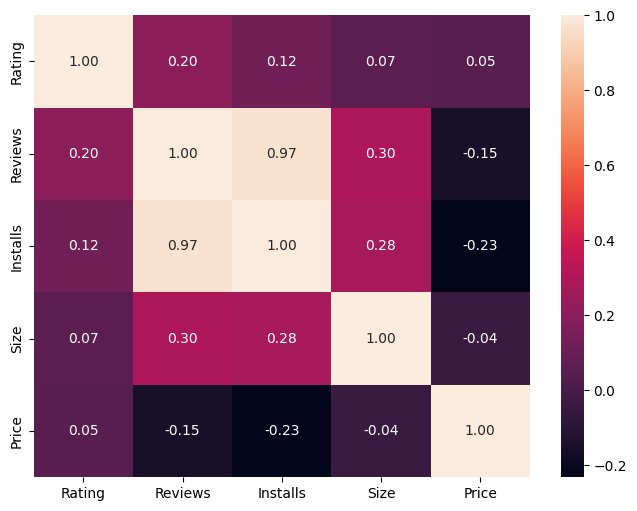

In [55]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

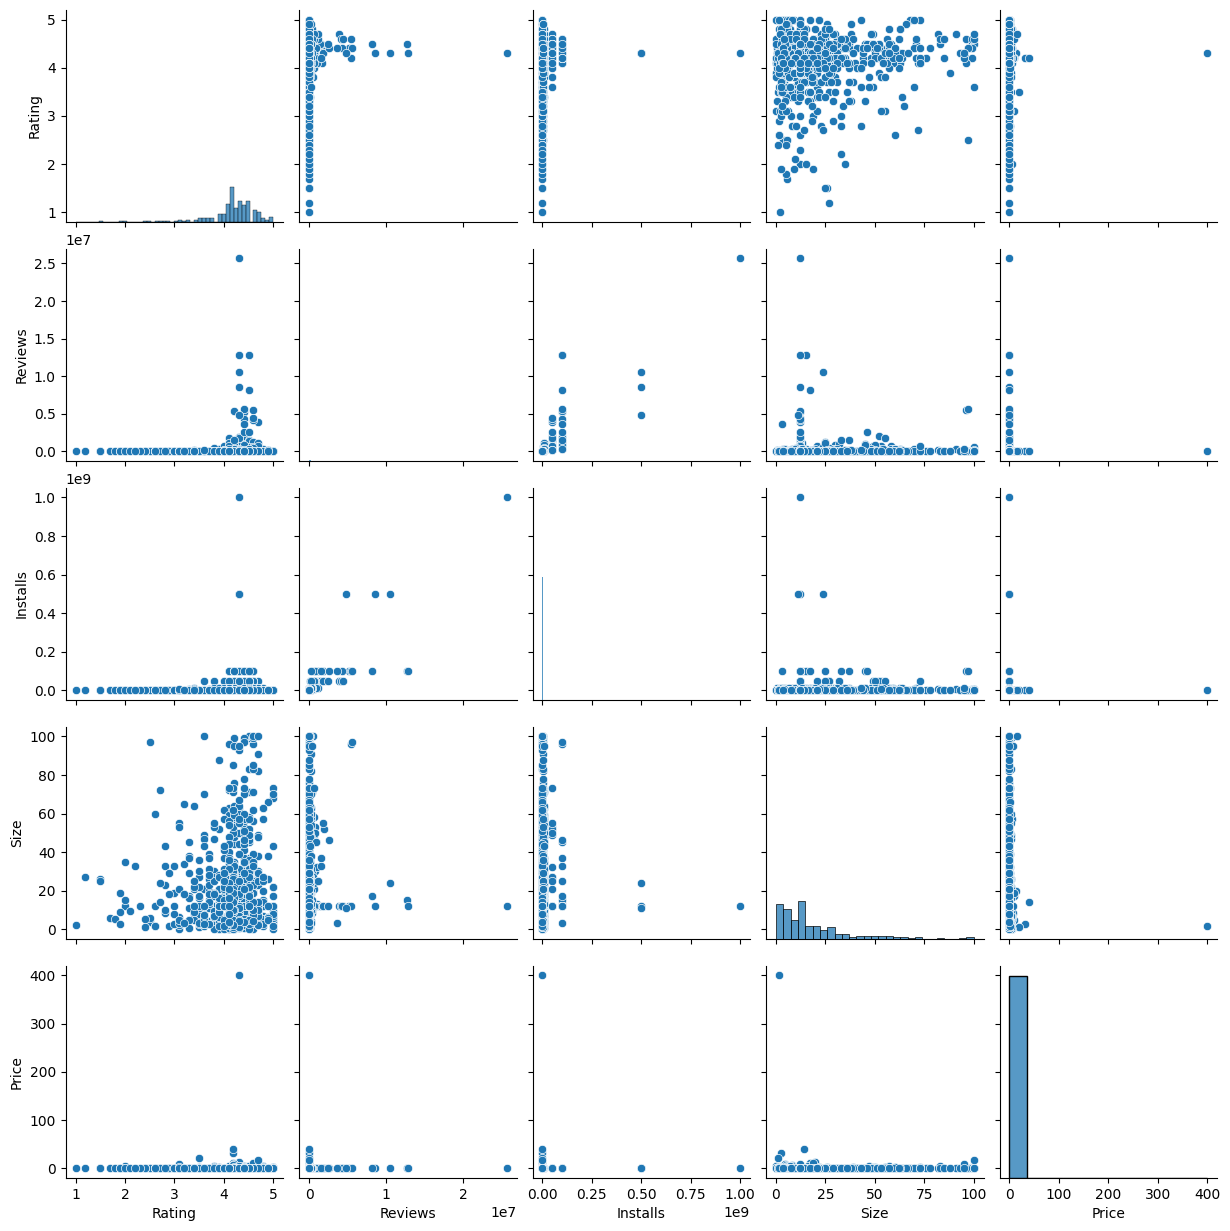

In [56]:
# pair plot
sns.pairplot(df[numeric_cols].sample(1000))
plt.show()

In [57]:
corr.shape

(5, 5)

In [58]:
# Multicolinearity
np.triu(np.ones(corr.shape), k=1).astype(bool)

array([[False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True],
       [False, False, False, False, False]])

In [59]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
upper.stack().sort_values(ascending=False)

Reviews   Installs    0.967714
          Size        0.297392
Installs  Size        0.278064
Rating    Reviews     0.200680
          Installs    0.119764
          Size        0.065137
          Price       0.054428
Size      Price      -0.042839
Reviews   Price      -0.150374
Installs  Price      -0.231575
dtype: float64

# Statistical Summary

In [66]:
summary = df[numeric_cols].describe().T

In [67]:
summary

,count,mean,std,min,25%,50%,75%,max
Rating,9659.0,4.176307e+00,4.940224e-01,1.000000,4.0,4.2,4.5,5.000000e+00
Reviews,9659.0,2.168041e+05,1.831430e+06,0.000000,25.0,969.0,29453.5,7.815831e+07
Installs,9659.0,7.798170e+06,5.376973e+07,0.000000,1000.0,100000.0,1000000.0,1.000000e+09
Size,9659.0,1.933038e+01,2.058505e+01,0.008301,5.3,12.0,25.0,1.000000e+02
Price,9659.0,1.097231e+00,1.685162e+01,0.000000,0.0,0.0,0.0,4.000000e+02


In [64]:
summary['median'] = (df[numeric_cols].median())

summary['variance'] = df[numeric_cols].var()

summary['skewness'] = df[numeric_cols].skew()

summary['kurtosis'] = df[numeric_cols].kurt()

summary

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
Rating,9659.0,4.176307e+00,4.940224e-01,1.000000,4.0,4.2,4.5,5.000000e+00,4.2,2.440581e-01,-1.912217,6.628402
Reviews,9659.0,2.168041e+05,1.831430e+06,0.000000,25.0,969.0,29453.5,7.815831e+07,969.0,3.354137e+12,26.569758,907.430590
Installs,9659.0,7.798170e+06,5.376973e+07,0.000000,1000.0,100000.0,1000000.0,1.000000e+09,100000.0,2.891184e+15,15.027398,254.884386
Size,9659.0,1.933038e+01,2.058505e+01,0.008301,5.3,12.0,25.0,1.000000e+02,12.0,4.237441e+02,1.859676,3.263236
Price,9659.0,1.097231e+00,1.685162e+01,0.000000,0.0,0.0,0.0,4.000000e+02,0.0,2.839770e+02,22.532793,520.000233
